In [2]:
# %%
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


In [3]:
# %%
# Initialize dictionary to collect results for genetic models.
# Here we include the original "only_genetics" model.
all_results = defaultdict(list)
base_path = "/n/data2/hms/dbmi/kyu/lab/chb3333/gem-patho/models/actual_final_results"

# Loop over the "only_genetics" model for the given batches and experiments.
for gen_image in ['only_genetics']:
    for batch in ['all_batch']:
        for exp in ['cancertypebatching_exp_0_phase2_10', 
                    'cancertypebatching_exp_1_phase2_0']:
            path = f"{base_path}/{gen_image}/{batch}/{exp}/global_test_cindices.csv"
            try:
                data = pd.read_csv(path)
                for cancer, c_idx in zip(data['cancer_type'], data['c_index']):
                    all_results['gen_image'].append(gen_image)
                    all_results['batch'].append(batch)
                    all_results['exp'].append(exp)
                    all_results['cancer'].append(cancer)
                    all_results['c_index'].append(c_idx)
            except Exception as e:
                # Skip missing or problematic files.
                print(f"Skipping file {path} due to error: {e}")


In [4]:
# %%
# Load additional genetic model results:
# (1) One-hot model
# (2) Cancer type–specific model
one_hot_model_path = "/home/chb3333/yulab/chb3333/gem-patho/models/clean_baseline_results/pure_genetics/one_hot_encoded/global_test_cindices.csv"
cancer_type_specific_models = "/home/chb3333/yulab/chb3333/gem-patho/models/per_ct_models/global_test_cindices_by_cancer.csv"

# Load one-hot model results.
try:
    data = pd.read_csv(one_hot_model_path)
    for cancer, c_idx in zip(data['cancer_type'], data['c_index']):
        all_results['gen_image'].append("one_hot")
        all_results['batch'].append("baseline")
        all_results['exp'].append("one_hot")
        all_results['cancer'].append(cancer)
        all_results['c_index'].append(c_idx)
except Exception as e:
    print(f"Error loading one hot model data: {e}")

# Load cancer type–specific model results.
try:
    data = pd.read_csv(cancer_type_specific_models)
    for cancer, c_idx in zip(data['cancer_type'], data['c_index']):
        all_results['gen_image'].append("ct_specific")
        all_results['batch'].append("baseline")
        all_results['exp'].append("ct_specific")
        all_results['cancer'].append(cancer)
        all_results['c_index'].append(c_idx)
except Exception as e:
    print(f"Error loading ct specific model data: {e}")


In [5]:
# %%
# Create a DataFrame from the collected results.
df = pd.DataFrame(all_results)
print("Raw Data:")
print(df.head())

# Group by model identifiers and calculate the average c-index and its standard error.
grouped = df.groupby(['gen_image', 'batch', 'exp'])['c_index'].agg(['mean', 'sem']).reset_index()
grouped.rename(columns={'mean': 'avg_c_index', 'sem': 'se_c_index'}, inplace=True)

# Create a column that uniquely identifies each model.
grouped["model"] = grouped["gen_image"] + "_" + grouped["batch"] + "_" + grouped["exp"]

# Compute the 95% confidence interval (CI = 1.96 * standard error).
grouped["ci95"] = 1.96 * grouped["se_c_index"]

print("Grouped Data:")
print(grouped)


Raw Data:
       gen_image      batch                                 exp cancer  \
0  only_genetics  all_batch  cancertypebatching_exp_0_phase2_10      8   
1  only_genetics  all_batch  cancertypebatching_exp_0_phase2_10      2   
2  only_genetics  all_batch  cancertypebatching_exp_0_phase2_10     10   
3  only_genetics  all_batch  cancertypebatching_exp_0_phase2_10     12   
4  only_genetics  all_batch  cancertypebatching_exp_0_phase2_10     11   

    c_index  
0  0.498182  
1  0.553148  
2  0.502162  
3  0.522422  
4  0.507760  
Grouped Data:
       gen_image      batch                                 exp  avg_c_index  \
0    ct_specific   baseline                         ct_specific     0.520680   
1        one_hot   baseline                             one_hot     0.522653   
2  only_genetics  all_batch  cancertypebatching_exp_0_phase2_10     0.520306   
3  only_genetics  all_batch   cancertypebatching_exp_1_phase2_0     0.529688   

   se_c_index                                 

In [6]:
grouped.iloc[[0, 1]] = grouped.iloc[[1, 0]].values


In [7]:
# %%
# Assign sequential model numbers to each aggregated group.
grouped["model_number"] = range(1, len(grouped) + 1)
print("Model Numbers:")
print(grouped[['model_number', 'model']])


Model Numbers:
   model_number                                              model
0             1                           one_hot_baseline_one_hot
1             2                   ct_specific_baseline_ct_specific
2             3  only_genetics_all_batch_cancertypebatching_exp...
3             4  only_genetics_all_batch_cancertypebatching_exp...


In [8]:
# %%
# Define model label mapping.
# For the two only_genetics experiments we assign different names,
# and assign names for one_hot and ct_specific groups.
model_labels = {
    "PhasedCTBatchModel": "Phased CT-Batch Model",  # for exp "cancertypebatching_exp_0_phase2_10"
    "UniformBatchModel": "Uniform Batch Model",      # for exp "cancertypebatching_exp_1_phase2_0"
    "one_hot": "One-Hot Encoding Model",
    "ct_specific": "Cancer-Type Specific Models"
}

# Function to generate the label based on the "model" string.
def get_model_label(model_str):
    if "cancertypebatching_exp_0_phase2_10" in model_str:
         return model_labels["PhasedCTBatchModel"]
    elif "cancertypebatching_exp_1_phase2_0" in model_str:
         return model_labels["UniformBatchModel"]
    elif model_str.startswith("one_hot"):
         return model_labels["one_hot"]
    elif model_str.startswith("ct_specific"):
         return model_labels["ct_specific"]
    else:
         return model_str

# Apply the label mapping.
grouped["model_label"] = grouped["model"].apply(get_model_label)


In [9]:
grouped

,gen_image,batch,exp,avg_c_index,se_c_index,model,ci95,model_number,model_label
0,one_hot,baseline,one_hot,0.522653,0.010235,one_hot_baseline_one_hot,0.020060,1,One-Hot Encoding Model
1,ct_specific,baseline,ct_specific,0.520680,0.009283,ct_specific_baseline_ct_specific,0.018195,2,Cancer-Type Specific Models
2,only_genetics,all_batch,cancertypebatching_exp_0_phase2_10,0.520306,0.012892,only_genetics_all_batch_cancertypebatching_exp...,0.025268,3,Phased CT-Batch Model
3,only_genetics,all_batch,cancertypebatching_exp_1_phase2_0,0.529688,0.017125,only_genetics_all_batch_cancertypebatching_exp...,0.033565,4,Uniform Batch Model


In [24]:
# %%
# Replace the color_map with:
color_map = {
    "only_genetics": "tab:green",
    "one_hot": "tab:purple",  # Your new purple
    "ct_specific": "tab:cyan"
}
# Function to determine the color based on the model's key.
def get_color(model_str):
    if model_str.startswith("only_genetics"):
        return color_map["only_genetics"]
    elif model_str.startswith("one_hot"):
        return color_map["one_hot"]
    elif model_str.startswith("ct_specific"):
        return color_map["ct_specific"]
    else:
        return "tab:gray"

# Map each model to its assigned color.
colors = grouped["model"].apply(get_color)


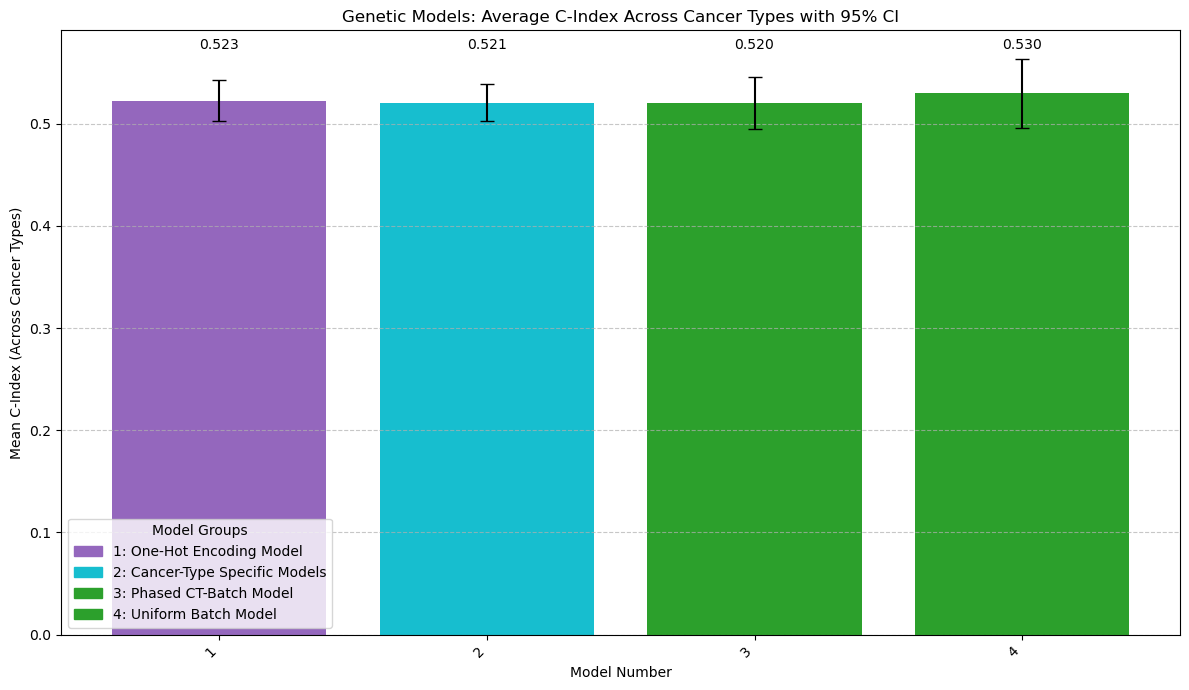

In [25]:
# %%
# Create the final bar plot.
plt.figure(figsize=(12, 7))
bars = plt.bar(range(len(grouped)), grouped["avg_c_index"],
               yerr=grouped["ci95"], capsize=5, color=colors)

# Keep numbers at the bottom.
plt.xticks(range(len(grouped)), grouped["model_number"], rotation=45, ha='right')
plt.ylabel("Mean C-Index (Across Cancer Types)")
plt.xlabel("Model Number")
plt.title("Genetic Models: Average C-Index Across Cancer Types with 95% CI")
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add numerical labels atop each bar.
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, 0.57, f'{height:.3f}', ha='center', va='bottom', fontsize=10)

# Build a custom legend.
# Build a custom legend that includes model numbers and labels.
legend_patches = []
for _, row in grouped.iterrows():
    legend_label = f"{row['model_number']}: {row['model_label']}"
    legend_patches.append(mpatches.Patch(color=get_color(row['model']), label=legend_label))
plt.legend(handles=legend_patches, title="Model Groups")

plt.show()


In [ ]:
grouped

,gen_image,batch,exp,avg_c_index,se_c_index,model,ci95,model_number,model_label
0,one_hot,baseline,one_hot,0.522653,0.010235,one_hot_baseline_one_hot,0.020060,1,One-Hot Encoding Model
1,ct_specific,baseline,ct_specific,0.520680,0.009283,ct_specific_baseline_ct_specific,0.018195,2,Cancer-Type Specific Models
2,only_genetics,all_batch,cancertypebatching_exp_0_phase2_10,0.520306,0.012892,only_genetics_all_batch_cancertypebatching_exp...,0.025268,3,Phased CT-Batch Model
3,only_genetics,all_batch,cancertypebatching_exp_1_phase2_0,0.529688,0.017125,only_genetics_all_batch_cancertypebatching_exp...,0.033565,4,Uniform Batch Model


METRICS CALCULATION

In [ ]:
cancer_mapping = {
    'ACC': 0, 'BLCA': 1, 'BRCA': 2, 'CESC': 3, 'CHOL': 4, 'CNTL': 5,
    'COAD': 6, 'DLBC': 7, 'ESCA': 8, 'FPPP': 9, 'GBM': 10, 'HNSC': 11,
    'KICH': 12, 'KIRC': 13, 'KIRP': 14, 'LAML': 15, 'LCML': 16, 'LGG': 17,
    'LIHC': 18, 'LUAD': 19, 'LUSC': 20, 'MESO': 21, 'MISC': 22, 'OV': 23,
    'PAAD': 24, 'PCPG': 25, 'PRAD': 26, 'READ': 27, 'SARC': 28, 'SKCM': 29,
    'STAD': 30, 'TGCT': 31, 'THCA': 32, 'THYM': 33, 'UCEC': 34, 'UCS': 35,
    'UVM': 36
}

inv_mapping = {v: k for k, v in cancer_mapping.items()}

In [ ]:
import pandas as pd
import numpy as np

# Replace with your actual file path
file_path = '/home/chb3333/yulab/chb3333/gem-patho/models/actual_final_results/only_genetics/all_batch/cancertypebatching_exp_0_phase2_10/global_test_cindices.csv'

# Load the CSV file
df = pd.read_csv(file_path)

# Calculate the average of the 'c_index' column
mean_c_index = df['c_index'].mean()
print("Average c_index:", mean_c_index)

# Make a copy to avoid SettingWithCopyWarning
filtered_df = df[df['c_index'] > 0.55].copy()

# Count how many rows have a c_index above 0.55
count_over = len(filtered_df)

# Calculate the average of the c_index values for those rows
average_over = filtered_df['c_index'].mean()

print("Count of c_index values over 0.55:", count_over)
print("Average c_index for values over 0.55:", average_over)

# Select the top 5 c_index values
top5 = df['c_index'].nlargest(5)

# Calculate mean and standard deviation
top5_avg = top5.mean()
top5_std = top5.std(ddof=1)  # sample std dev

# Compute standard error
top5_se = top5_std / np.sqrt(len(top5))

# Compute 95% confidence interval using normal approximation (1.96 * SE)
top5_ci95 = 1.96 * top5_se

print("Average of top 5 c_index values:", top5_avg)
print("Standard deviation of top 5 c_index values:", top5_std)
print("Standard error:", top5_se)
print(f"95% CI: [{top5_avg - top5_ci95:.4f}, {top5_avg + top5_ci95:.4f}]")

# Replace cancer_type using inverse mapping
filtered_df['cancer_type'] = filtered_df['cancer_type'].map(inv_mapping)

print("\nRows with c_index > 0.55:")
print(filtered_df)


Average c_index: 0.5203056081475042
Count of c_index values over 0.55: 9
Average c_index for values over 0.55: 0.6095490517579581
Average of top 5 c_index values: 0.6482966835483179
Standard deviation of top 5 c_index values: 0.05423020703566064
Standard error: 0.024252485873124906
95% CI: [0.6008, 0.6958]

Rows with c_index > 0.55:
   cancer_type   c_index
1         BRCA  0.553148
5          LGG  0.690692
6         LAML  0.552941
8         LUSC  0.564534
11        DLBC  0.714894
15         ACC  0.638530
18         UCS  0.582670
20        KIRP  0.573834
32        UCEC  0.614697


In [ ]:
# Replace with your actual file path
file_path = '/home/chb3333/yulab/chb3333/gem-patho/models/actual_final_results/only_genetics/all_batch/cancertypebatching_exp_1_phase2_0/global_test_cindices.csv'

# Load the CSV file
df = pd.read_csv(file_path)

# Calculate the average of the 'c_index' column
mean_c_index = df['c_index'].mean()
print("Average c_index:", mean_c_index)

# Make a copy to avoid SettingWithCopyWarning
filtered_df = df[df['c_index'] > 0.55].copy()

# Count how many rows have a c_index above 0.55
count_over = len(filtered_df)

# Calculate the average of the c_index values for those rows
average_over = filtered_df['c_index'].mean()

print("Count of c_index values over 0.55:", count_over)
print("Average c_index for values over 0.55:", average_over)

# Select the top 5 c_index values
top5 = df['c_index'].nlargest(5)

# Calculate mean and standard deviation
top5_avg = top5.mean()
top5_std = top5.std(ddof=1)  # sample std dev

# Compute standard error
top5_se = top5_std / np.sqrt(len(top5))

# Compute 95% confidence interval using normal approximation (1.96 * SE)
top5_ci95 = 1.96 * top5_se

print("Average of top 5 c_index values:", top5_avg)
print("Standard deviation of top 5 c_index values:", top5_std)
print("Standard error:", top5_se)
print(f"95% CI: [{top5_avg - top5_ci95:.4f}, {top5_avg + top5_ci95:.4f}]")

# Replace cancer_type using inverse mapping
filtered_df['cancer_type'] = filtered_df['cancer_type'].map(inv_mapping)

print("\nRows with c_index > 0.55:")
print(filtered_df)

Average c_index: 0.5296881298618622
Count of c_index values over 0.55: 12
Average c_index for values over 0.55: 0.6269998900802896
Average of top 5 c_index values: 0.6813246702993302
Standard deviation of top 5 c_index values: 0.03981485769654004
Standard error: 0.017805745664788843
95% CI: [0.6464, 0.7162]

Rows with c_index > 0.55:
   cancer_type   c_index
5          LGG  0.713443
9         LUAD  0.575302
11        DLBC  0.731915
13        CHOL  0.570234
14        BLCA  0.551383
15         ACC  0.670308
18         UCS  0.603006
19         UVM  0.596154
20        KIRP  0.640058
21        PRAD  0.650900
26        PCPG  0.610256
32        UCEC  0.611040


In [ ]:
one_hot_model_path = "/home/chb3333/yulab/chb3333/gem-patho/models/clean_baseline_results/pure_genetics/one_hot_encoded/global_test_cindices.csv"


# Load the CSV file
df = pd.read_csv(one_hot_model_path)

# Calculate the average of the 'c_index' column
mean_c_index = df['c_index'].mean()

print("Average c_index:", mean_c_index)


filtered_df = df[df['c_index'] > 0.55]

# Count how many rows have a c_index above 0.55
count_over = len(filtered_df)

# Calculate the average of the c_index values for those rows
average_over = filtered_df['c_index'].mean()

print("Count of c_index values over 0.55:", count_over)
print("Average c_index for values over 0.55:", average_over)

# Select the top 5 c_index values
top5 = df['c_index'].nlargest(5)

# Calculate mean and standard deviation
top5_avg = top5.mean()
top5_std = top5.std(ddof=1)  # sample std dev

# Compute standard error
top5_se = top5_std / np.sqrt(len(top5))

# Compute 95% confidence interval using normal approximation (1.96 * SE)
top5_ci95 = 1.96 * top5_se

print("Average of top 5 c_index values:", top5_avg)
print("Standard deviation of top 5 c_index values:", top5_std)
print("Standard error:", top5_se)
print(f"95% CI: [{top5_avg - top5_ci95:.4f}, {top5_avg + top5_ci95:.4f}]")

print("\nRows with c_index > 0.55:")
print(filtered_df)

Average c_index: 0.5226525500353183
Count of c_index values over 0.55: 9
Average c_index for values over 0.55: 0.5978077820904698
Average of top 5 c_index values: 0.6177937666614278
Standard deviation of top 5 c_index values: 0.026840302189086323
Standard error: 0.012003348046286685
95% CI: [0.5943, 0.6413]

Rows with c_index > 0.55:
   cancer_type   c_index
1         BRCA  0.589470
5          LGG  0.652346
11        DLBC  0.578723
17        LIHC  0.565203
21        PRAD  0.559383
27        THCA  0.599532
29        TGCT  0.639296
30        PAAD  0.587992
32        UCEC  0.608325


In [ ]:
cancer_type_specific_models = "/home/chb3333/yulab/chb3333/gem-patho/models/per_ct_models/global_test_cindices_by_cancer.csv"


# Load the CSV file
df = pd.read_csv(cancer_type_specific_models)

# Calculate the average of the 'c_index' column
mean_c_index = df['c_index'].mean()

print("Average c_index:", mean_c_index)


filtered_df = df[df['c_index'] > 0.55]

# Count how many rows have a c_index above 0.55
count_over = len(filtered_df)

# Calculate the average of the c_index values for those rows
average_over = filtered_df['c_index'].mean()

print("Count of c_index values over 0.55:", count_over)
print("Average c_index for values over 0.55:", average_over)

# Select the top 5 c_index values
top5 = df['c_index'].nlargest(5)

# Calculate mean and standard deviation
top5_avg = top5.mean()
top5_std = top5.std(ddof=1)  # sample std dev

# Compute standard error
top5_se = top5_std / np.sqrt(len(top5))

# Compute 95% confidence interval using normal approximation (1.96 * SE)
top5_ci95 = 1.96 * top5_se

print("Average of top 5 c_index values:", top5_avg)
print("Standard deviation of top 5 c_index values:", top5_std)
print("Standard error:", top5_se)
print(f"95% CI: [{top5_avg - top5_ci95:.4f}, {top5_avg + top5_ci95:.4f}]")

print("\nRows with c_index > 0.55:")
print(filtered_df)

Average c_index: 0.5206800149416625
Count of c_index values over 0.55: 9
Average c_index for values over 0.55: 0.5913444018396061
Average of top 5 c_index values: 0.6143141321701736
Standard deviation of top 5 c_index values: 0.025904910043509064
Standard error: 0.01158502796166066
95% CI: [0.5916, 0.6370]

Rows with c_index > 0.55:
   cancer_type   c_index
6         DLBC  0.644444
12        KIRP  0.558128
14         LGG  0.576874
18        MESO  0.554042
21        PCPG  0.582051
22        PRAD  0.626149
29        THYM  0.561485
30        UCEC  0.592904
32         UVM  0.626022
